# Gradient-as-Bucket-View Parameter Sweep Analysis

Plots results from `run_perf_sweep.sh` to visualize how `gradient_as_bucket_view` improvement scales with parameter count.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import glob
import os

In [2]:
# Find the latest sweep result, or set manually
sweep_dirs = sorted(glob.glob("../ddp-example/data/sweep_*/sweep_results.csv"))
if sweep_dirs:
    CSV_PATH = sweep_dirs[-1]
    print(f"Using latest: {CSV_PATH}")
else:
    CSV_PATH = "../ddp-example/data/sweep_20260302_173826/sweep_results.csv"  # <-- set manually
    print(f"No sweep found. Set CSV_PATH manually.")

Using latest: ../ddp-example/data/sweep_20260302_173826/sweep_results.csv


In [3]:
df = pd.read_csv(CSV_PATH)
df

,num_params,expo,bwd_gb0_mean,bwd_gb0_std,bwd_gb1_mean,bwd_gb1_std,bwd_improve_pct,iter_gb0_mean,iter_gb0_std,iter_gb1_mean,iter_gb1_std,iter_improve_pct,fwd_copy_gb0_mean,fwd_copy_gb1_mean,fwd_copy_improve_pct,rev_copy_gb0_mean,rev_copy_gb1_mean,rev_copy_improve_pct
0,32768,15,0.000403,0.000030,0.000389,0.000119,3.42,0.000757,0.000044,0.000741,0.000127,2.09,131,36,72.5,29,0,100.0
1,65536,16,0.000408,0.000038,0.000379,0.000022,7.15,0.000796,0.000057,0.000742,0.000030,6.73,130,37,71.5,30,0,100.0
2,131072,17,0.000419,0.000030,0.000397,0.000057,5.35,0.000790,0.000032,0.000767,0.000066,2.90,129,37,71.3,29,0,100.0
3,262144,18,0.000420,0.000027,0.000390,0.000042,7.14,0.000792,0.000032,0.000762,0.000053,3.76,128,36,71.9,32,0,100.0
4,524288,19,0.000704,0.000097,0.000667,0.000190,5.26,0.001158,0.000098,0.001116,0.000191,3.68,157,64,59.2,45,0,100.0
5,1048576,20,0.000885,0.000062,0.000827,0.000151,6.54,0.001391,0.000076,0.001333,0.000155,4.14,189,94,50.3,63,0,100.0
6,2097152,21,0.001400,0.000106,0.001306,0.000129,6.75,0.002093,0.000114,0.001984,0.000129,5.22,262,167,36.3,99,0,100.0
7,4194304,22,0.002390,0.000084,0.002263,0.000101,5.33,0.003470,0.000114,0.003321,0.000117,4.28,404,323,20.0,175,1,99.4
8,8388608,23,0.004620,0.000350,0.004632,0.000450,-0.27,0.006502,0.000495,0.006793,0.000613,-4.47,705,647,8.2,344,3,99.1
9,16777216,24,0.008168,0.000118,0.007691,0.000101,5.84,0.011335,0.000121,0.010821,0.000106,4.53,1250,1178,5.8,649,4,99.4


In [4]:
def format_params(val):
    if val >= 1e6:
        return f"{val/1e6:.0f}M"
    elif val >= 1e3:
        return f"{val/1e3:.0f}K"
    return str(int(val))

x_labels = [format_params(v) for v in df["num_params"]]

## 1. Backward Pass Time: gb=0 vs gb=1

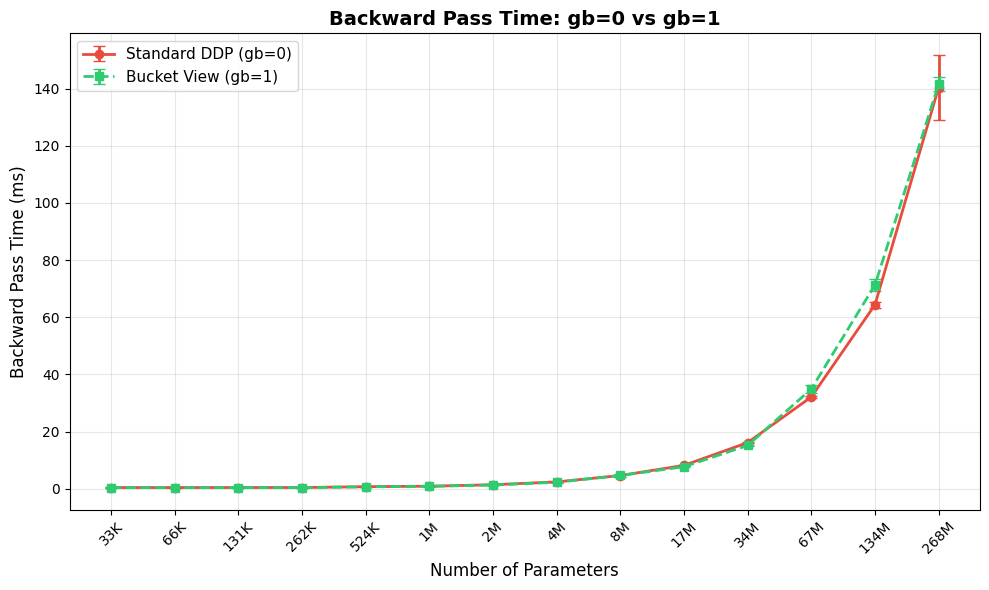

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(range(len(x_labels)), df["bwd_gb0_mean"] * 1000, yerr=df["bwd_gb0_std"] * 1000,
            fmt="o-", label="Standard DDP (gb=0)", capsize=4, color="#e74c3c", linewidth=2)
ax.errorbar(range(len(x_labels)), df["bwd_gb1_mean"] * 1000, yerr=df["bwd_gb1_std"] * 1000,
            fmt="s--", label="Bucket View (gb=1)", capsize=4, color="#2ecc71", linewidth=2)

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Backward Pass Time (ms)", fontsize=12)
ax.set_title("Backward Pass Time: gb=0 vs gb=1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Backward Pass Improvement %

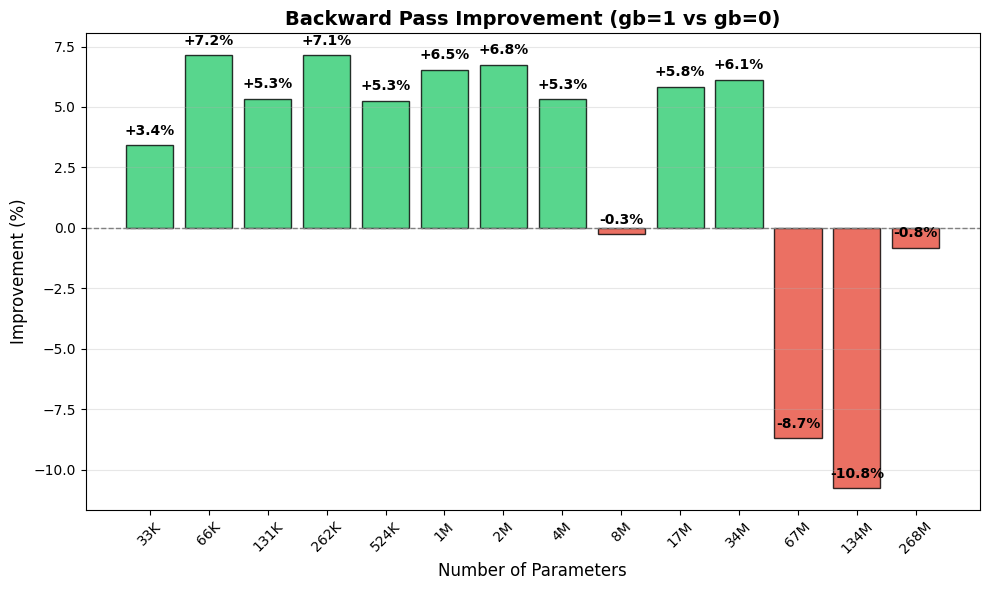

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df["bwd_improve_pct"]]
bars = ax.bar(range(len(x_labels)), df["bwd_improve_pct"], color=colors,
              edgecolor="black", alpha=0.8)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")

for bar, val in zip(bars, df["bwd_improve_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Improvement (%)", fontsize=12)
ax.set_title("Backward Pass Improvement (gb=1 vs gb=0)", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Forward Copy Time (grad → bucket): gb=0 vs gb=1

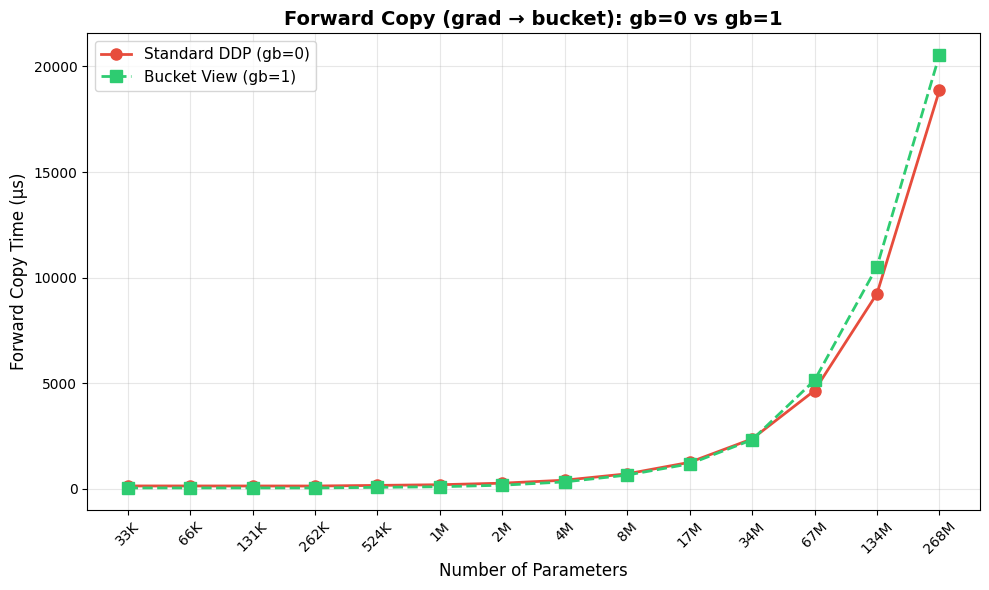

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(len(x_labels)), df["fwd_copy_gb0_mean"], "o-",
        label="Standard DDP (gb=0)", color="#e74c3c", markersize=8, linewidth=2)
ax.plot(range(len(x_labels)), df["fwd_copy_gb1_mean"], "s--",
        label="Bucket View (gb=1)", color="#2ecc71", markersize=8, linewidth=2)

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Forward Copy Time (μs)", fontsize=12)
ax.set_title("Forward Copy (grad → bucket): gb=0 vs gb=1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Forward Copy Improvement %

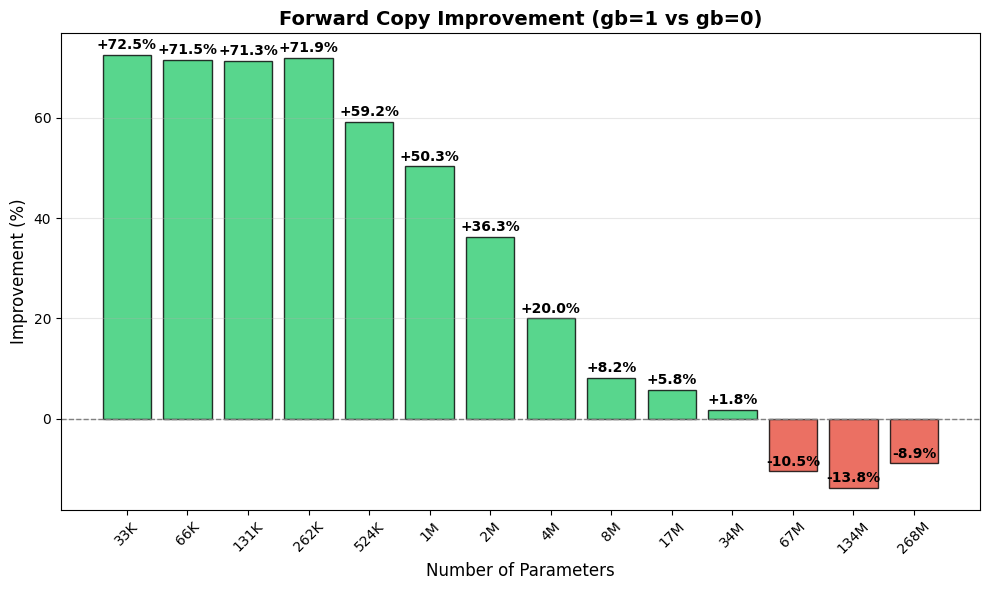

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df["fwd_copy_improve_pct"]]
bars = ax.bar(range(len(x_labels)), df["fwd_copy_improve_pct"], color=colors,
              edgecolor="black", alpha=0.8)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")

for bar, val in zip(bars, df["fwd_copy_improve_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Improvement (%)", fontsize=12)
ax.set_title("Forward Copy Improvement (gb=1 vs gb=0)", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Reverse Copy Time (bucket → grad): gb=0 vs gb=1

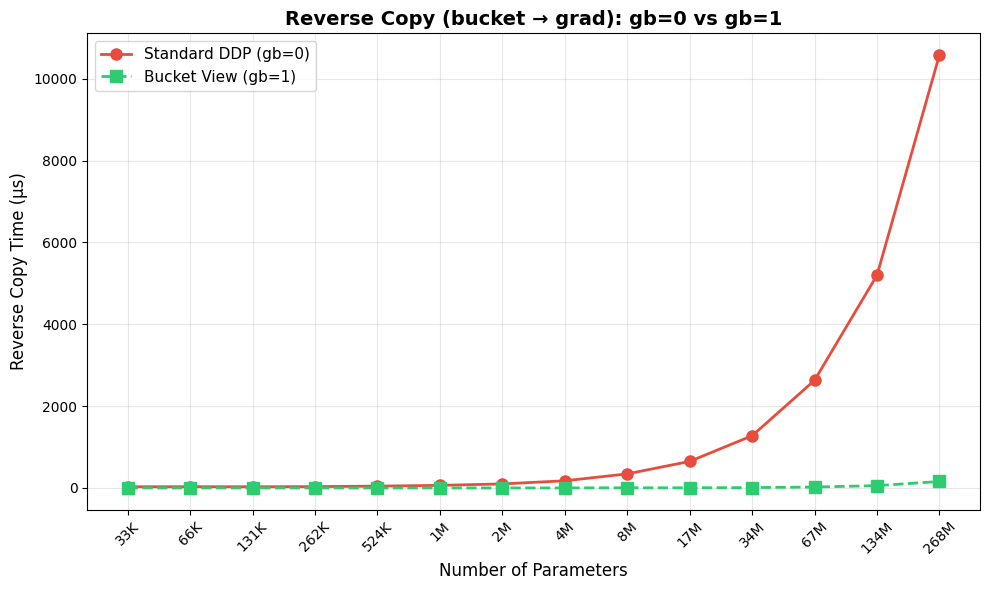

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(len(x_labels)), df["rev_copy_gb0_mean"], "o-",
        label="Standard DDP (gb=0)", color="#e74c3c", markersize=8, linewidth=2)
ax.plot(range(len(x_labels)), df["rev_copy_gb1_mean"], "s--",
        label="Bucket View (gb=1)", color="#2ecc71", markersize=8, linewidth=2)

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Reverse Copy Time (μs)", fontsize=12)
ax.set_title("Reverse Copy (bucket → grad): gb=0 vs gb=1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Reverse Copy Improvement %

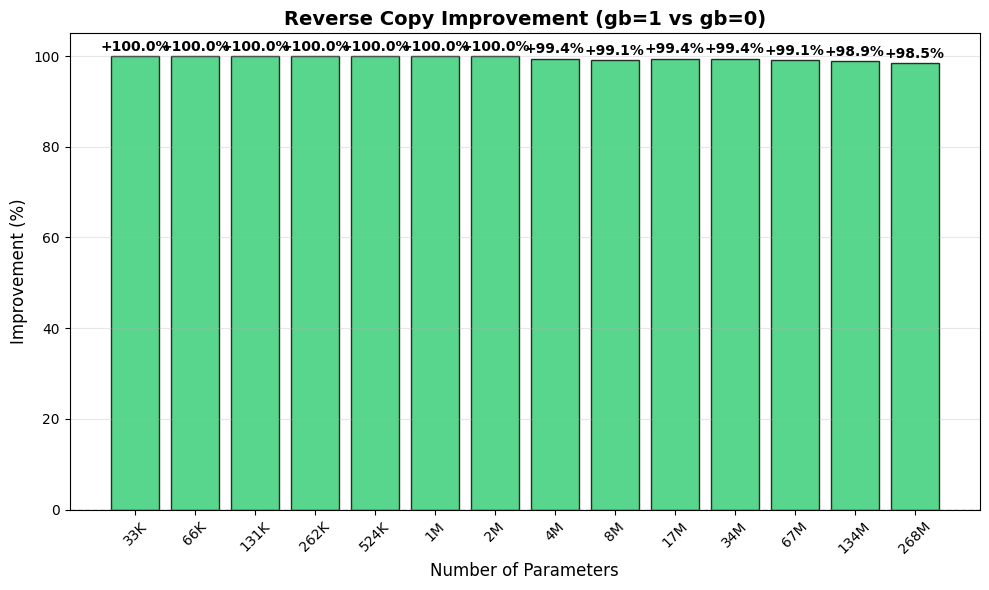

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df["rev_copy_improve_pct"]]
bars = ax.bar(range(len(x_labels)), df["rev_copy_improve_pct"], color=colors,
              edgecolor="black", alpha=0.8)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")

for bar, val in zip(bars, df["rev_copy_improve_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters", fontsize=12)
ax.set_ylabel("Improvement (%)", fontsize=12)
ax.set_title("Reverse Copy Improvement (gb=1 vs gb=0)", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Combined 3×2 Overview

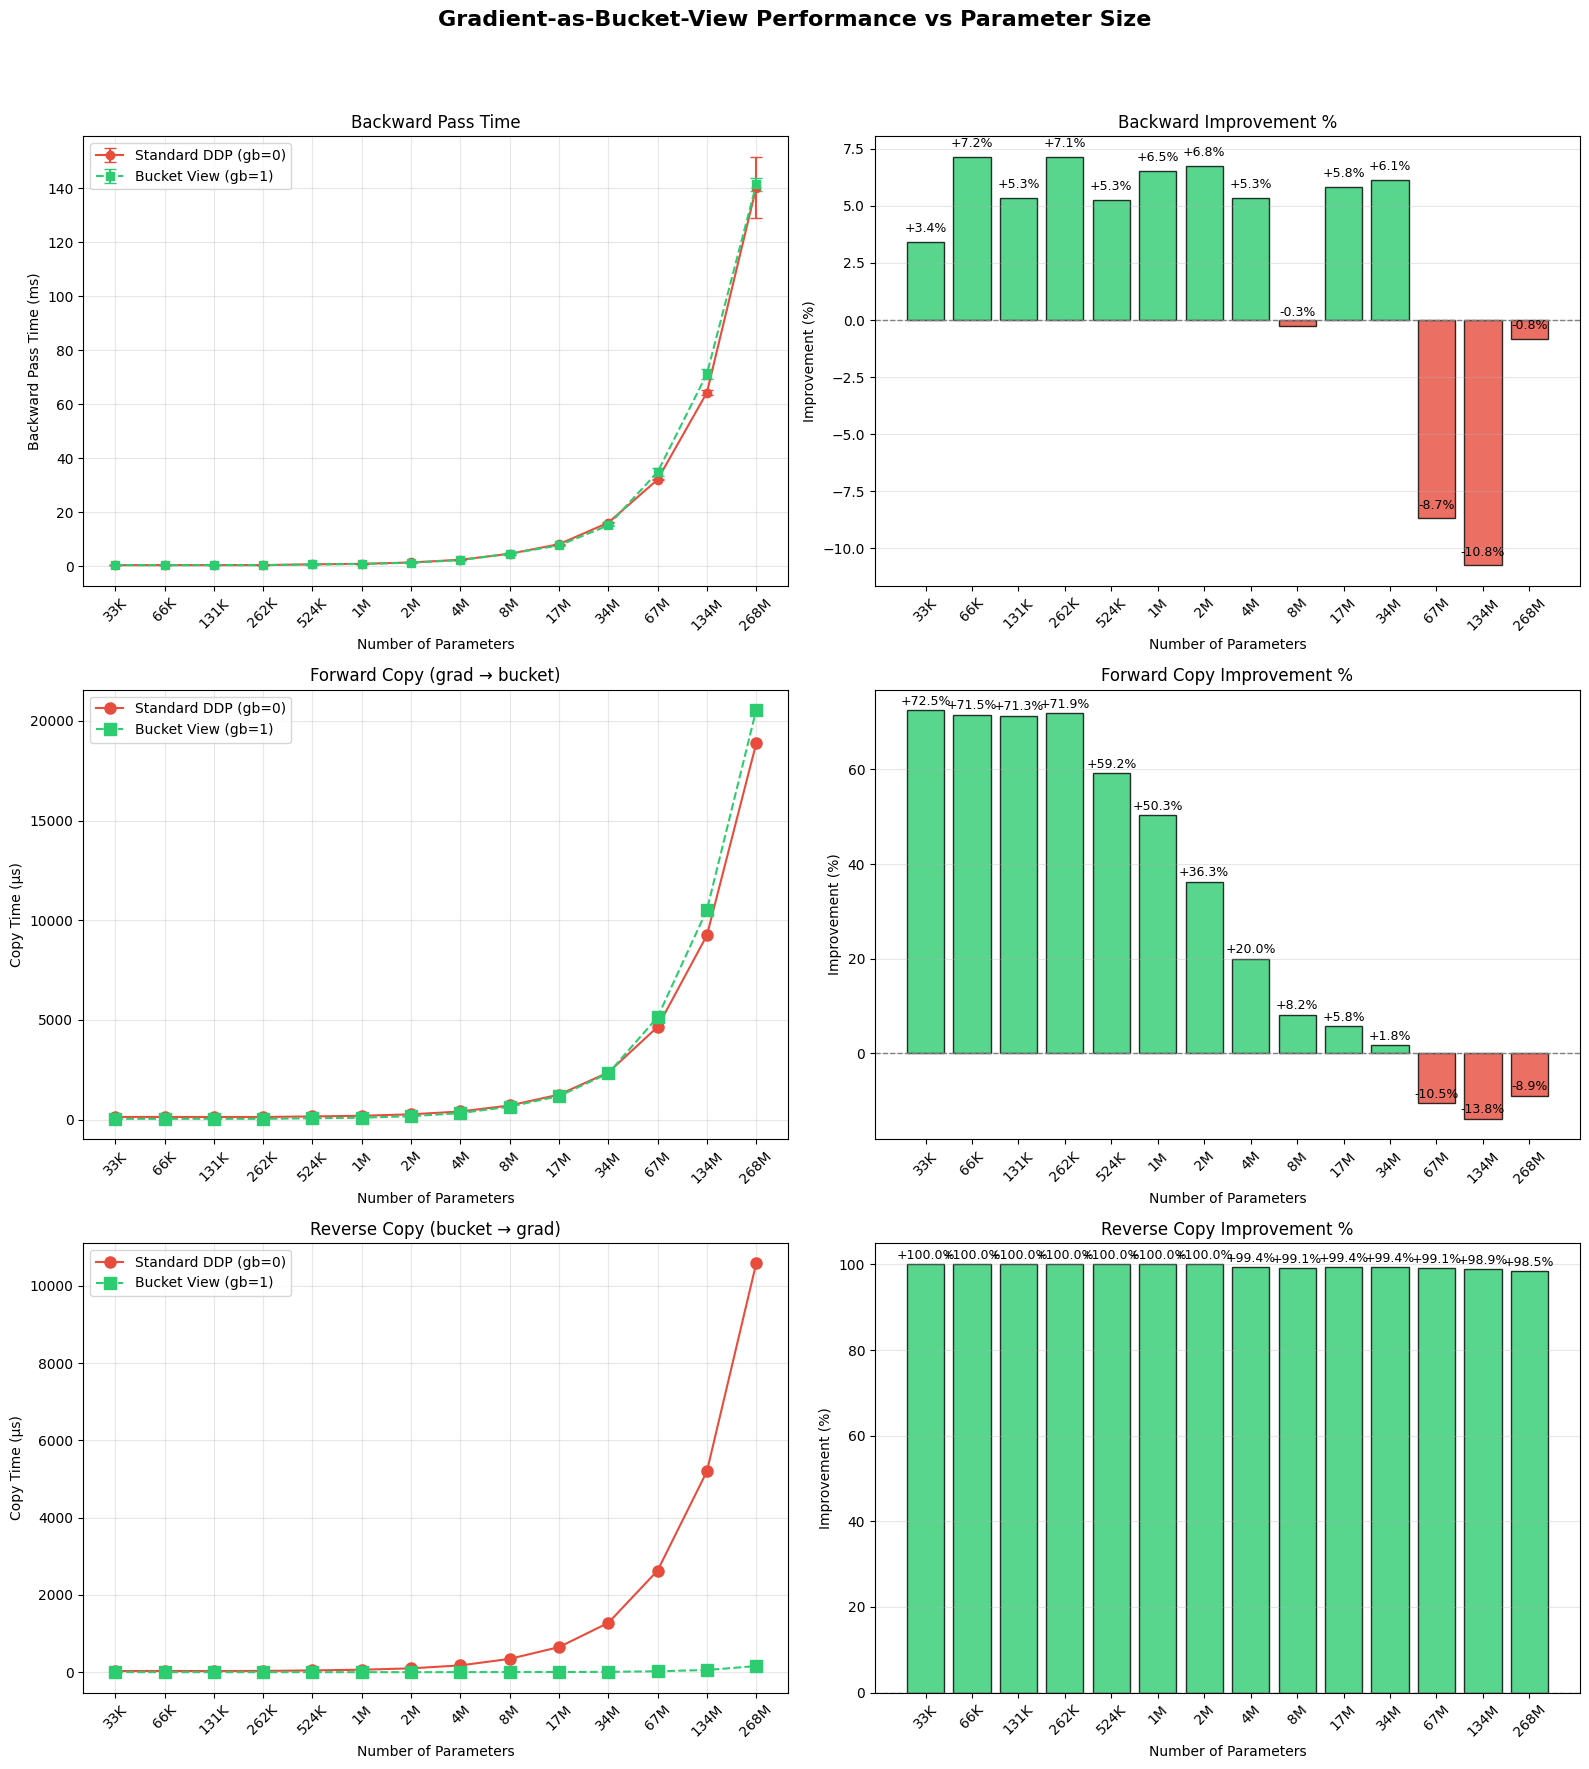

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Gradient-as-Bucket-View Performance vs Parameter Size",
             fontsize=16, fontweight="bold", y=0.98)

# Row 1 Left: Backward time comparison
ax = axes[0, 0]
ax.errorbar(range(len(x_labels)), df["bwd_gb0_mean"] * 1000, yerr=df["bwd_gb0_std"] * 1000,
            fmt="o-", label="Standard DDP (gb=0)", capsize=4, color="#e74c3c")
ax.errorbar(range(len(x_labels)), df["bwd_gb1_mean"] * 1000, yerr=df["bwd_gb1_std"] * 1000,
            fmt="s--", label="Bucket View (gb=1)", capsize=4, color="#2ecc71")
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Backward Pass Time (ms)")
ax.set_title("Backward Pass Time")
ax.legend()
ax.grid(True, alpha=0.3)

# Row 1 Right: Backward improvement %
ax = axes[0, 1]
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df["bwd_improve_pct"]]
bars = ax.bar(range(len(x_labels)), df["bwd_improve_pct"], color=colors,
              edgecolor="black", alpha=0.8)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Improvement (%)")
ax.set_title("Backward Improvement %")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df["bwd_improve_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=9)

# Row 2 Left: Forward copy time comparison
ax = axes[1, 0]
ax.plot(range(len(x_labels)), df["fwd_copy_gb0_mean"], "o-",
        label="Standard DDP (gb=0)", color="#e74c3c", markersize=8)
ax.plot(range(len(x_labels)), df["fwd_copy_gb1_mean"], "s--",
        label="Bucket View (gb=1)", color="#2ecc71", markersize=8)
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Copy Time (μs)")
ax.set_title("Forward Copy (grad → bucket)")
ax.legend()
ax.grid(True, alpha=0.3)

# Row 2 Right: Forward copy improvement %
ax = axes[1, 1]
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df["fwd_copy_improve_pct"]]
bars = ax.bar(range(len(x_labels)), df["fwd_copy_improve_pct"], color=colors,
              edgecolor="black", alpha=0.8)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Improvement (%)")
ax.set_title("Forward Copy Improvement %")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df["fwd_copy_improve_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=9)

# Row 3 Left: Reverse copy time comparison
ax = axes[2, 0]
ax.plot(range(len(x_labels)), df["rev_copy_gb0_mean"], "o-",
        label="Standard DDP (gb=0)", color="#e74c3c", markersize=8)
ax.plot(range(len(x_labels)), df["rev_copy_gb1_mean"], "s--",
        label="Bucket View (gb=1)", color="#2ecc71", markersize=8)
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Copy Time (μs)")
ax.set_title("Reverse Copy (bucket → grad)")
ax.legend()
ax.grid(True, alpha=0.3)

# Row 3 Right: Reverse copy improvement %
ax = axes[2, 1]
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df["rev_copy_improve_pct"]]
bars = ax.bar(range(len(x_labels)), df["rev_copy_improve_pct"], color=colors,
              edgecolor="black", alpha=0.8)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Improvement (%)")
ax.set_title("Reverse Copy Improvement %")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df["rev_copy_improve_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()